# Step 1b (Quarantine) — Do the OTHER survey items track the sentiment trajectory?

**Why this is quarantined.** The main Step-1 contest validates the sentiment models against a single
valence target (the `positive emotion` item). This notebook is **exploratory**: it asks whether the
model's sentiment trajectory *also* covaries with the other 15 survey items — trait ratings
(trustworthy, warm & kind, agreeable, competent...), viewer-stance items (empathize, understand,
like, similar), and so on. It is kept **separate** so these many exploratory correlations never leak
back into or bias the primary model-selection result.

**Two questions**
- **1b.3** For each sentiment model, how strongly does its group-level valence correlate with *each*
  of the 16 behavioral items? (What do the models actually track — just emotion, or a broad
  "good-person" halo?)
- **1b.4** Which behavioral items co-move with the `positive emotion` item itself? (Is our sentiment
  ground truth an isolated construct, or one face of a bundle?)

**Grain.** Everything is at the same group-level `(group, Character, Run)` grid used in Step 1
(3 groups x 4 characters x 10 runs = 120 rows), so both sides of every correlation are matched.
This is **descriptive**: 16 items x 6 models is many comparisons, so read effect sizes and patterns,
not single p-values (a Benjamini-Hochberg FDR note is included at the end).

## 1b.1 · Rebuild the group-level behavioral trajectories (all 16 items)

Same loader logic as Step 1.1 (auto-locate `data/charsurvey/`, NaN-safe, run = block), but here we
**keep all 16 items** instead of collapsing to one target. Output `gt_all`: one row per
`(group, Character, Run)` with 16 item columns, averaged across the ~12-14 participants per group.

In [1]:
import pandas as pd, numpy as np, scipy.io as sio
from pathlib import Path
from scipy.stats import spearmanr

CHARACTERS  = ["jack", "kate", "kevin", "randall"]
CHAR_COLS   = ["jack", "kate", "randall", "kevin"]   # block column order (instruction.pdf p.6)
_CANDIDATES = [Path("data/charsurvey"), Path("charsurvey"),
               Path("socialaha-beh/charsurvey"), Path("data/socialaha-beh/charsurvey")]
BEH_DIR     = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
ITEM_LABELS = [str(x[0]) for x in sio.loadmat(BEH_DIR / "labels.mat")["labels"].ravel()]

def group_from_id(pid):
    d = [c for c in str(pid) if c.isdigit()]
    return int(d[0]) if d else np.nan

def load_participant(path):
    pid = Path(path).stem
    m = sio.loadmat(path)
    rows = []
    for b in range(1, 11):                          # block{1..10} == Run 1..10
        blk = m[f"block{b}"].astype(float)          # float keeps NaN (skipped ratings)
        for ci, ch in enumerate(CHAR_COLS):
            rec = {"Participant": pid, "group": group_from_id(pid), "Character": ch, "Run": b}
            for ri, lab in enumerate(ITEM_LABELS):
                rec[lab] = float(blk[ri, ci])       # never impute; means below skip NaN
            rows.append(rec)
    return pd.DataFrame(rows)

mat_files = sorted(p for p in BEH_DIR.glob("s*.mat") if p.name != "labels.mat")
assert mat_files, f"No s*.mat in {BEH_DIR.resolve()}"
beh = pd.concat([load_participant(p) for p in mat_files], ignore_index=True)
beh["Character"] = beh["Character"].str.lower().str.strip()
beh = beh[beh["Character"].isin(CHARACTERS)]

# group-level trajectories, ALL 16 items (skipna=True averaging)
gt_all = beh.groupby(["group", "Character", "Run"])[ITEM_LABELS].mean().reset_index()
print("gt_all shape:", gt_all.shape, "| expect 120 x (3 keys + 16 items)")
gt_all.head()

gt_all shape: (120, 19) | expect 120 x (3 keys + 16 items)


,group,Character,Run,warm and kind,intelligent,agreeable,extraverted,impulsive,emotionally stable,open-minded,trustworthy,competent,rational behavior,positive emotion,good relationship,empathize,understand,like,similar
0,1,jack,1,5.666667,4.500000,5.333333,5.166667,3.916667,5.083333,4.833333,5.250000,5.416667,5.500000,6.500000,6.166667,4.250000,3.250000,4.833333,3.166667
1,1,jack,2,6.153846,4.923077,5.461538,5.230769,4.153846,5.846154,5.153846,5.769231,5.461538,5.923077,5.230769,6.307692,5.000000,4.923077,5.615385,2.846154
2,1,jack,3,6.000000,4.923077,5.000000,5.461538,4.846154,3.846154,4.230769,5.692308,5.538462,4.307692,4.384615,6.230769,5.307692,5.461538,5.461538,2.923077
3,1,jack,4,6.076923,5.307692,5.615385,5.076923,3.846154,3.692308,4.923077,5.538462,5.769231,5.692308,2.307692,5.615385,6.153846,5.769231,5.615385,3.307692
4,1,jack,5,6.461538,5.153846,5.461538,5.307692,4.230769,4.461538,4.615385,5.846154,5.615385,5.461538,4.076923,6.230769,5.384615,5.615385,5.615385,3.230769


## 1b.2 · Group-level sentiment valence per model

Reuse the Step-0 baselines. Valence = `positive - negative` for the four classifiers, `valence`
for the lexicons. Average each model to the same `(group, Character, Run)` grid, then widen so each
model is a `val_<model>` column. `WINNER` = the Step-1 contest winner, used as the reference sentiment
trajectory for sorting.

In [2]:
MODEL_FILES = {
    "Twitter_RoB": "results/baselines/00__character_vectors_simple_Twitter_RoB.csv",
    "RoBERTa_ZS":  "results/baselines/00__character_vectors_simple_RoBERTa_ZS.csv",
    "VADER":       "results/baselines/00__character_vectors_simple_VADER.csv",
    "Flair":       "results/baselines/00__character_vectors_simple_Flair.csv",
    "SiEBERT":     "results/baselines/00__character_vectors_simple_SiEBERT.csv",
    "BERTweet":    "results/baselines/00__character_vectors_simple_BERTweet.csv",
    "Warriner":    "results/baselines/00b__character_vectors_simple_Warriner_val.csv",
    "NRC_VAD":     "results/baselines/00b__character_vectors_simple_NRC_VAD_val.csv",
}
WINNER = "Twitter_RoB"   # from Step 1 step1_model_ranking.csv

model_wide = None
model_names = []
for name, path in MODEL_FILES.items():
    try:
        d = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[skip {name}: {path} not found]"); continue
    d["Character"] = d["Character"].str.lower().str.strip()
    if {"positive", "negative"}.issubset(d.columns):
        d["valence"] = d["positive"] - d["negative"]
    elif "valence" not in d.columns:
        print(f"[skip {name}: no valence]"); continue
    d["group"] = d["Participant"].map(group_from_id)
    d = d[d["Run"].between(1, 10)]                   # drop Step-0 Run==-1 sentinel
    g = (d.groupby(["group", "Character", "Run"])["valence"].mean()
           .reset_index().rename(columns={"valence": f"val_{name}"}))
    model_wide = g if model_wide is None else model_wide.merge(g, on=["group","Character","Run"])
    model_names.append(name)

print("models:", model_names, "| winner:", WINNER)
print("model_wide shape:", model_wide.shape)
model_wide.head()

models: ['Twitter_RoB', 'RoBERTa_ZS', 'VADER', 'Flair', 'SiEBERT', 'BERTweet', 'Warriner', 'NRC_VAD'] | winner: Twitter_RoB
model_wide shape: (120, 11)


,group,Character,Run,val_Twitter_RoB,val_RoBERTa_ZS,val_VADER,val_Flair,val_SiEBERT,val_BERTweet,val_Warriner,val_NRC_VAD
0,1,jack,1,0.584461,0.457982,0.259222,0.370808,0.769783,0.760567,6.783955,0.233667
1,1,jack,2,0.145482,0.285773,0.213778,-0.068863,0.556300,0.266068,6.422011,0.250551
2,1,jack,3,0.213005,0.237790,0.145875,0.242533,0.746317,0.502770,6.525104,0.258832
3,1,jack,4,-0.314087,-0.631884,-0.000667,-0.471888,0.108879,-0.460518,5.985775,0.151277
4,1,jack,5,0.083114,-0.124732,0.121600,-0.205975,0.191059,0.170270,6.442165,0.198237


## 1b.3 · Does each survey item track model sentiment?

For every model's valence, Spearman-correlate its group-level trajectory with **each** of the 16
behavioral items across the 120 rows. Rows = items, columns = models. The `positive emotion` row is
the sentiment ground truth (should be high); watch whether trait items like `trustworthy` /
`warm and kind` / `agreeable` correlate almost as strongly — that would say the models capture a
broad positivity halo, not emotion specifically. Viewer-stance items (`empathize`, `understand`)
correlating with valence would say people warm to characters they feel positive about.

In [3]:
merged = gt_all.merge(model_wide, on=["group", "Character", "Run"], how="inner")

rows = []
for item in ITEM_LABELS:
    row = {"survey_item": item}
    for name in model_names:
        rho, p = spearmanr(merged[item], merged[f"val_{name}"], nan_policy="omit")
        row[name] = round(rho, 3)
    rows.append(row)

item_vs_model = (pd.DataFrame(rows)
                   .sort_values(WINNER, ascending=False)
                   .reset_index(drop=True))
Path("results/step1b").mkdir(parents=True, exist_ok=True)
item_vs_model.to_csv("results/step1b/01b__step1b_item_vs_model_spearman.csv", index=False)
print(f"Spearman(item trajectory, model valence)  -- sorted by {WINNER}:")
print(item_vs_model.to_string(index=False))

Spearman(item trajectory, model valence)  -- sorted by Twitter_RoB:
       survey_item  Twitter_RoB  RoBERTa_ZS  VADER  Flair  SiEBERT  BERTweet  Warriner  NRC_VAD
  positive emotion        0.597       0.549  0.459  0.416    0.301     0.526     0.436    0.153
emotionally stable        0.569       0.515  0.424  0.477    0.326     0.505     0.435    0.211
       open-minded        0.524       0.449  0.342  0.499    0.381     0.454     0.371    0.232
 good relationship        0.499       0.473  0.345  0.425    0.365     0.435     0.334    0.083
         competent        0.493       0.401  0.284  0.534    0.443     0.435     0.449    0.353
         agreeable        0.473       0.398  0.317  0.466    0.346     0.383     0.333    0.159
     warm and kind        0.463       0.438  0.345  0.463    0.374     0.401     0.302    0.112
       trustworthy        0.462       0.390  0.307  0.495    0.389     0.414     0.366    0.194
 rational behavior        0.424       0.370  0.277  0.370    0.235  

## 1b.4 · Which behavioral items co-move with the sentiment item?

A Spearman correlation matrix among the 16 survey items plus the winning model's valence, over the
120 group-level rows. The column for `positive emotion` (and for `val_<WINNER>`) tells you which
constructs bundle with sentiment. A heatmap makes the clusters visible.

Spearman with 'positive emotion' (survey), ranked:
emotionally stable    0.886
good relationship     0.711
rational behavior     0.701
warm and kind         0.628
open-minded           0.624
agreeable             0.613
val_Twitter_RoB       0.597
trustworthy           0.539
like                  0.514
competent             0.470
understand            0.374
intelligent           0.365
similar               0.337
empathize             0.250
extraverted          -0.080
impulsive            -0.380

Spearman with model sentiment val_Twitter_RoB, ranked:
positive emotion      0.597
emotionally stable    0.569
open-minded           0.524
good relationship     0.499
competent             0.493
agreeable             0.473
warm and kind         0.463
trustworthy           0.462
rational behavior     0.424
intelligent           0.392
like                  0.390
understand            0.303
similar               0.240
empathize             0.207
extraverted          -0.098
impulsive            -0.1

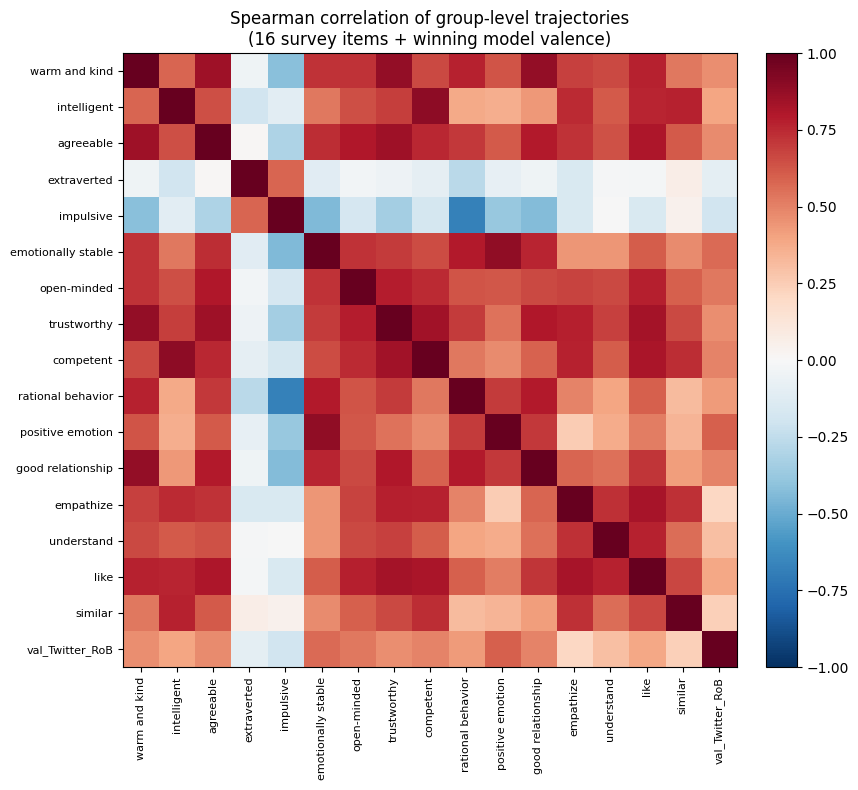

saved step1b_correlation_heatmap.png


In [4]:
cols = ITEM_LABELS + [f"val_{WINNER}"]
corr = merged[cols].corr(method="spearman")

# what co-moves with the sentiment item, ranked
print("Spearman with 'positive emotion' (survey), ranked:")
print(corr["positive emotion"].drop("positive emotion").sort_values(ascending=False).round(3).to_string())
print()
print(f"Spearman with model sentiment val_{WINNER}, ranked:")
print(corr[f"val_{WINNER}"].drop(f"val_{WINNER}").sort_values(ascending=False).round(3).to_string())
corr.to_csv("results/step1b/01b__step1b_item_correlation_matrix.csv")

# heatmap (optional viz)
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=8)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
    ax.set_title("Spearman correlation of group-level trajectories\n(16 survey items + winning model valence)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.savefig("results/step1b/01b__step1b_correlation_heatmap.png", dpi=140); plt.show()
    print("saved step1b_correlation_heatmap.png")
except Exception as e:
    print("heatmap skipped:", e)

## Findings — what the sentiment signal actually tracks (output above)

The winning model's valence correlates with `positive emotion` (Spearman 0.597) but **almost as
strongly** with `emotionally stable` (0.569), `open-minded` (0.524), `good relationship` (0.499),
`competent` (0.493), `agreeable` (0.473), `warm and kind` (0.463) and `trustworthy` (0.462) — and is
**negative / near-zero** for `impulsive` (-0.194) and `extraverted` (-0.098). So the model's
"sentiment" is really a broad **evaluative "good-person" halo**, not emotion in isolation.

The survey shows the same bundling internally: `positive emotion` correlates 0.89 with `emotionally
stable`, 0.71 with `good relationship`, 0.70 with `rational behavior`, and 0.63 with `warm and kind`.
So the ground-truth target is itself one face of a general **positivity dimension** — the valence axis
that social-cognitive neuroscience (Tamir et al. 2016) says organizes person representation in the brain.

**Boundary of the representation.** Items that *don't* move with valence — `intelligent`, `extraverted`,
`impulsive` — mark what a valence-only sentiment vector cannot capture, motivating richer non-valence
features (impressions / USE, per the parent paper) at the brain step.

**Note (curiosity):** `Flair` and `Warriner` correlate more with trait/competence items (e.g. Flair
with `competent` 0.534, `intelligent` 0.509) than with `positive emotion` — a hint they track a
slightly different, more "trait-like" signal than the transformers' cleaner valence.

**Still exploratory / descriptive** — 16×6 correlations at the group level; see the caveats cell below.

## Interpretation & caveats

**How to read it.**
- If non-valence trait items (`trustworthy`, `warm and kind`, `agreeable`, `competent`) correlate with
  model valence *almost as strongly* as `positive emotion` does, the sentiment models are picking up a
  broad **evaluative / "good person" halo**, not emotion per se. That is itself a finding worth reporting.
- If viewer-stance items (`empathize`, `understand`, `like`, `similar`) track valence, that speaks to
  how felt positivity relates to engagement with a character.
- Items that *don't* move with valence (e.g. `intelligent`, `rational behavior`, `impulsive`) mark the
  boundary of what a valence-only sentiment representation can capture — motivating richer, non-valence
  features later (impressions / USE, per the parent paper).

**Caveats.**
1. **Exploratory, not confirmatory.** 16 items x 6 models = 96 correlations; treat as descriptive.
   Apply Benjamini-Hochberg FDR if you want to flag "survivors":
   `from statsmodels.stats.multitest import multipletests`.
2. **Group-level.** Same ecological-fallacy / inflated-effect-size caveats as Step 1 — conclusions are
   about group trajectories, not individuals.
3. **This does not change model selection.** The primary contest still uses `positive emotion`; this
   notebook only characterizes *what else* the sentiment signal happens to align with.

**Open question for Hayoung:** are any of these items (e.g. `trustworthy`, `empathize`) worth promoting
to a secondary validation target, or kept purely as this descriptive context?